<a href="https://colab.research.google.com/github/megha-5/Speech-to-Text-Summarization-System/blob/main/gall_blladder_cancer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow opencv-python flask flask-ngrok pydot graphviz


In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, concatenate, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from flask import Flask, request
from flask_ngrok import run_with_ngrok
from google.colab import files
import zipfile

In [ ]:
uploaded = files.upload()  # Upload Gall_Bladder_dataset.zip

for filename in uploaded.keys():
    extract_path = "/content/Gall_Bladder_dataset"
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"Dataset extracted to {extract_path}")


Saving gallblader dataset.zip to gallblader dataset.zip
Dataset extracted to /content/Gall_Bladder_dataset


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5
CLASSES = ["abn", "bmt", "malg", "nml", "stn"]

train_dir = "/content/Gall_Bladder_dataset/data/training"
val_dir   = "/content/Gall_Bladder_dataset/data/validation"


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1605 images belonging to 5 classes.
Found 689 images belonging to 5 classes.


In [ ]:
def build_hybrid_model(num_classes=NUM_CLASSES):
    input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    base1 = ResNet50(weights='imagenet', include_top=False, input_tensor=input_layer)
    base2 = VGG16(weights='imagenet', include_top=False, input_tensor=input_layer)

    # Freeze base models
    for layer in base1.layers:
        layer.trainable = False
    for layer in base2.layers:
        layer.trainable = False

    x1 = GlobalAveragePooling2D()(base1.output)
    x2 = GlobalAveragePooling2D()(base2.output)

    merged = concatenate([x1, x2])
    dense = Dense(256, activation='relu')(merged)
    dropout = Dropout(0.5)(dense)
    output = Dense(num_classes, activation='softmax')(dropout)

    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

hybrid_model = build_hybrid_model(NUM_CLASSES)
hybrid_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 38,959,301 (148.62 MB)

 Trainable params: 656,901 (2.51 MB)

 Non-trainable params: 38,302,400 (146.11 MB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = hybrid_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


51/51 ━━━━━━━━━━━━━━━━━━━━ 1852s 36s/step - accuracy: 0.3173 - loss: 1.6979 - val_accuracy: 0.5501 - val_loss: 1.2209


In [ ]:
model_path = "/content/gallbladder_hybrid.h5"
hybrid_model.save(model_path)
print(f"Model saved to {model_path}")


Model saved to /content/gallbladder_hybrid.h5


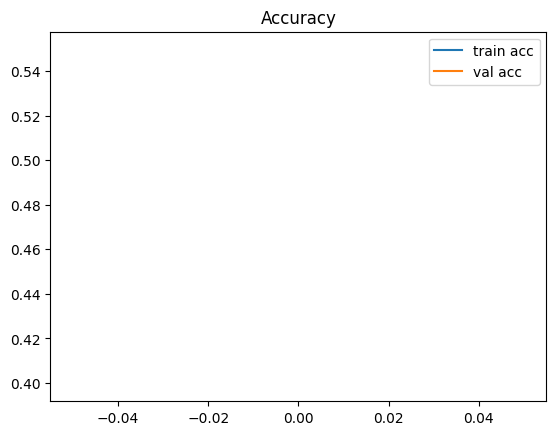

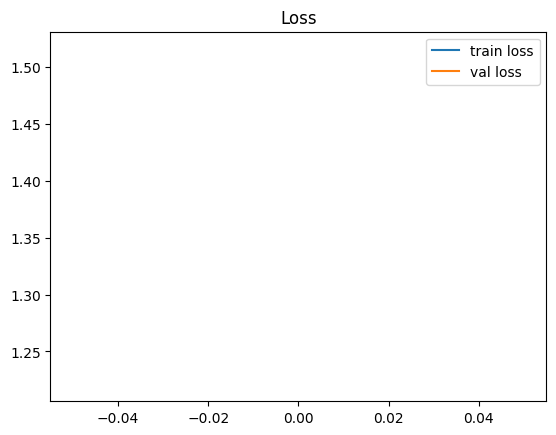

In [ ]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("Loss")
plt.legend()
plt.show()

In [ ]:
val_generator.reset()
preds = hybrid_model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(val_generator.classes, y_pred))
print("\nClassification Report:")
print(classification_report(val_generator.classes, y_pred, target_names=CLASSES))


22/22 ━━━━━━━━━━━━━━━━━━━━ 532s 24s/step
Confusion Matrix:
[[247   0   0   0   0]
 [ 18   0   0   0  41]
 [ 61   0   0   0  20]
 [129   0   0   0   1]
 [ 40   0   0   0 132]]

Classification Report:
              precision    recall  f1-score   support

         abn       0.50      1.00      0.67       247
         bmt       0.00      0.00      0.00        59
        malg       0.00      0.00      0.00        81
         nml       0.00      0.00      0.00       130
         stn       0.68      0.77      0.72       172

    accuracy                           0.55       689
   macro avg       0.24      0.35      0.28       689
weighted avg       0.35      0.55      0.42       689



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
app = Flask(__name__)
model = load_model(model_path)

def preprocess(img):
    if img.shape[-1] != 3:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return np.expand_dims(img, axis=0)

@app.route("/", methods=["GET","POST"])
def upload():
    if request.method == "POST":
        file = request.files["image"]
        npimg = np.frombuffer(file.read(), np.uint8)
        img = cv2.imdecode(npimg, cv2.IMREAD_COLOR)
        img = preprocess(img)
        pred = model.predict(img)
        result = CLASSES[np.argmax(pred)]
        return f"<h1>Prediction: {result}</h1>"
    return '''
    <form method="POST" enctype="multipart/form-data">
        <input type="file" name="image">
        <input type="submit" value="Upload">
    </form>
    '''

# Run Flask with ngrok
run_with_ngrok(app)
app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-14:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
           